# 01 - Forward Model and Wiener Deconvolution

This notebook is the notebook version of our first 2D lensless simulation. It follows the same learning style as the DiffuserCam tutorial: introduce the model, run a small simulation, inspect the reconstruction, and connect the result back to the math.

The simple model is:

$$ y = h * x + n $$

where `x` is the scene, `h` is the PSF, and `y` is the sensor measurement.

## Setup

The project code lives in `src/diffusercam_sim`. This cell makes imports work whether Jupyter was launched from the repo root or from inside the `notebooks` folder.

In [2]:
from pathlib import Path
import sys
import json

import numpy as np
from PIL import Image

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'diffusercam_sim').exists():
            return candidate
    raise RuntimeError('Could not find project root containing src/diffusercam_sim')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from diffusercam_sim import circular_convolve2d, psnr, residual_relative_l2, ssim
from diffusercam_sim.phantoms import add_gaussian_noise, make_diffuser_like_psf, make_synthetic_scene
from diffusercam_sim.fft_ops import centered_fft2, centered_ifft2
from diffusercam_sim.viz import save_montage

RESULT_DIR = PROJECT_ROOT / 'results' / 'notebooks' / '01_forward_model_wiener'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('E:/RIT/Spring2026/ComputationalImaging/DiffuserCam2026')

## Scene and PSF

The Point Spread Function (PSF) is the calibration fingerprint of the lensless system. In a real DiffuserCam, we would measure it using a point source. Here we use a synthetic sparse caustic PSF so the model remains easy to inspect.

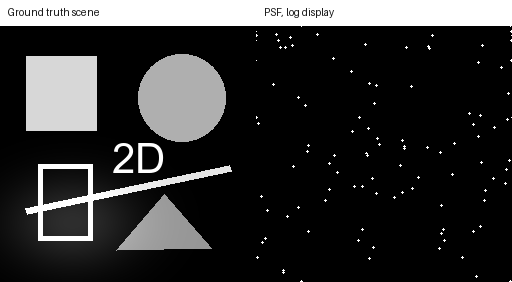

In [3]:
image_size = 256
scene = make_synthetic_scene(image_size)
psf = make_diffuser_like_psf(image_size)

save_montage(
    [
        ('Ground truth scene', scene),
        ('PSF, log display', psf),
    ],
    RESULT_DIR / 'scene_and_psf.png',
    columns=2,
)
Image.open(RESULT_DIR / 'scene_and_psf.png')

## Forward Model

For this first notebook we use same-size circular convolution. It is not the final physical model, but it gives a clean Fourier-domain view:

$$ Y = H X + N $$

In [4]:
snr_db = 35.0
clean_measurement = circular_convolve2d(scene, psf)
measurement, noise_sigma = add_gaussian_noise(clean_measurement, snr_db)

noise_sigma

0.004027567821853798

## Direct Inverse vs Wiener

The direct inverse divides by the optical transfer function:

$$ \hat{X} = Y / H $$

This becomes unstable when `|H|` is small. Wiener deconvolution stabilizes it:

$$ \hat{X} = \frac{H^*Y}{|H|^2 + \lambda} $$

In [5]:
def direct_inverse(measurement: np.ndarray, psf: np.ndarray, epsilon: float) -> np.ndarray:
    h_fft = centered_fft2(psf)
    y_fft = centered_fft2(measurement)
    x_fft = y_fft / np.where(np.abs(h_fft) < epsilon, epsilon, h_fft)
    return np.real(centered_ifft2(x_fft))

def wiener_deconvolution(measurement: np.ndarray, psf: np.ndarray, regularization: float) -> np.ndarray:
    h_fft = centered_fft2(psf)
    y_fft = centered_fft2(measurement)
    x_fft = np.conj(h_fft) * y_fft / (np.abs(h_fft) ** 2 + regularization)
    return np.real(centered_ifft2(x_fft))

direct = np.clip(direct_inverse(measurement, psf, epsilon=1e-8), 0.0, 1.0)
wiener = np.clip(wiener_deconvolution(measurement, psf, regularization=1e-4), 0.0, 1.0)
predicted = circular_convolve2d(wiener, psf)
residual = predicted - measurement

In [6]:
metrics = {
    'noise_sigma': noise_sigma,
    'measurement_psnr_vs_clean_db': psnr(clean_measurement, measurement),
    'direct_inverse_psnr_db': psnr(scene, direct),
    'direct_inverse_ssim': ssim(scene, direct),
    'wiener_psnr_db': psnr(scene, wiener),
    'wiener_ssim': ssim(scene, wiener),
    'wiener_relative_residual_l2': residual_relative_l2(measurement, predicted),
}
print(json.dumps(metrics, indent=2))

{
  "noise_sigma": 0.004027567821853798,
  "measurement_psnr_vs_clean_db": 47.85939659213669,
  "direct_inverse_psnr_db": 15.282263094224966,
  "direct_inverse_ssim": 0.22837603992991745,
  "wiener_psnr_db": 21.282927854334464,
  "wiener_ssim": 0.30109894625628786,
  "wiener_relative_residual_l2": 0.0985724928170839
}


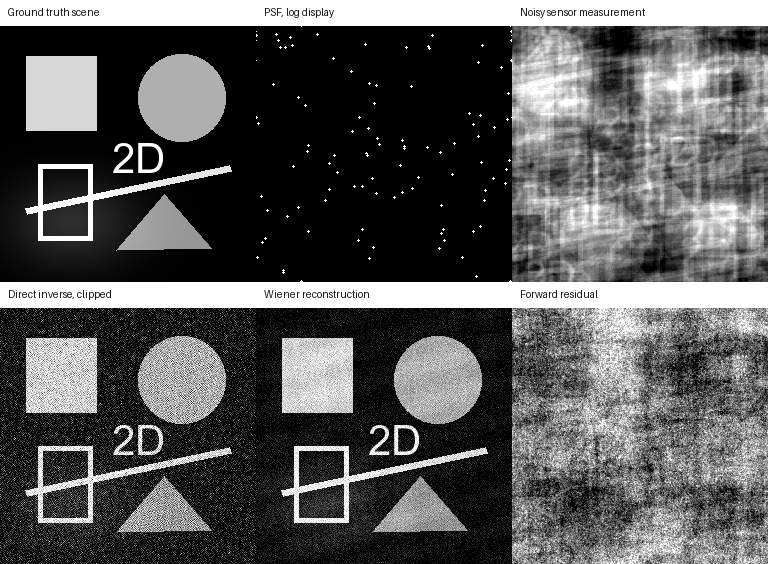

In [7]:
save_montage(
    [
        ('Ground truth scene', scene),
        ('PSF, log display', psf),
        ('Noisy sensor measurement', measurement),
        ('Direct inverse, clipped', direct),
        ('Wiener reconstruction', wiener),
        ('Forward residual', np.abs(residual)),
    ],
    RESULT_DIR / 'wiener_montage.png',
    columns=3,
)
Image.open(RESULT_DIR / 'wiener_montage.png')

## What to Notice

- The PSF does not simply blur like a lens; it multiplexes the scene into a coded sensor pattern.
- Direct inversion can recover structure when the PSF has useful Fourier diversity, but it amplifies noise.
- Wiener regularization reduces that amplification by refusing to divide too aggressively where `|H|` is weak.

Next notebook: replace circular convolution with padded linear convolution and solve the reconstruction iteratively with PGD and FISTA.